In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

In [2]:
files = ["M13_0001.fits", "M13_0002.fits", "M13_0003.fits", "M13_0004.fits", "M13_0005.fits"]
data_files = []
for file in files:
    with fits.open(file) as hdul:
        info = {
            "data": hdul[0].data,
            "header": hdul[0].header
        }
        data_files.append(info)

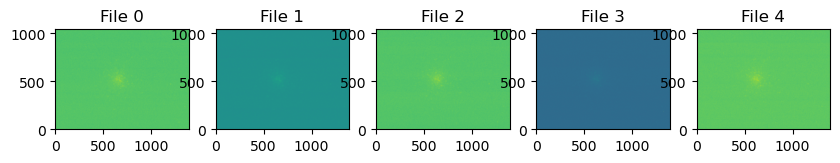

In [3]:
fig, axes = plt.subplots(1, 5, figsize = (10, 2))
for i in range(5):
    axes[i].imshow(data_files[i]["data"], origin = "lower")
    axes[i].set_title(f"File {i}")

plt.show()

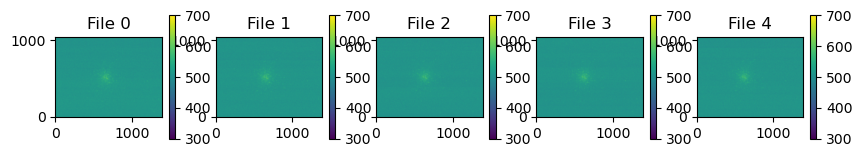

In [10]:
fig, axes = plt.subplots(1, 5, figsize = (10, 2))
for i in range(5):
    image = axes[i].imshow(data_files[i]["data"], origin = "lower", vmin = 300 , vmax = 700)
    axes[i].set_title(f"File {i}")
    fig.colorbar(image, ax=axes[i], shrink=0.8)
plt.show()


In [5]:
#the image all have the same color scheme, but the dot of yellow is better defined than before

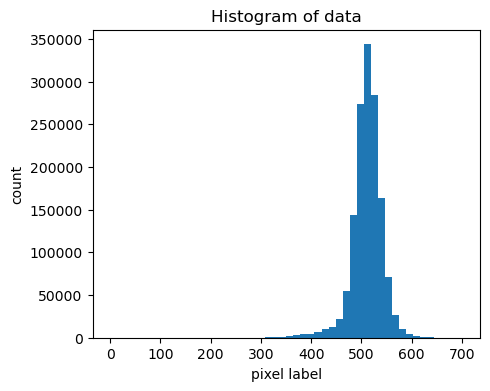

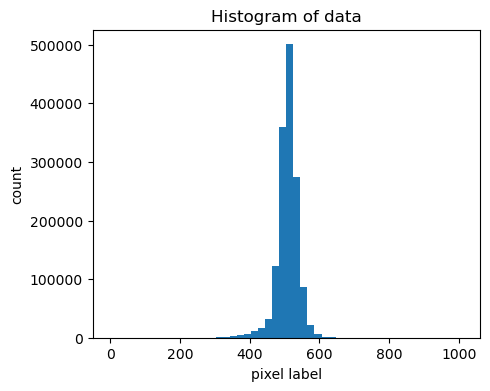

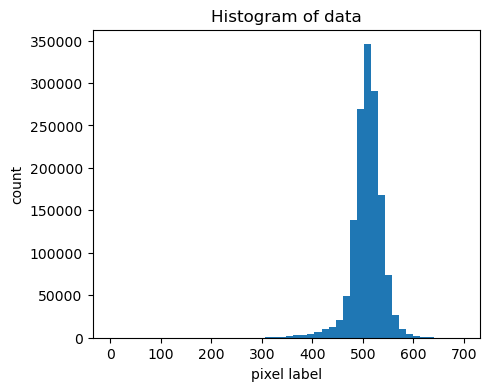

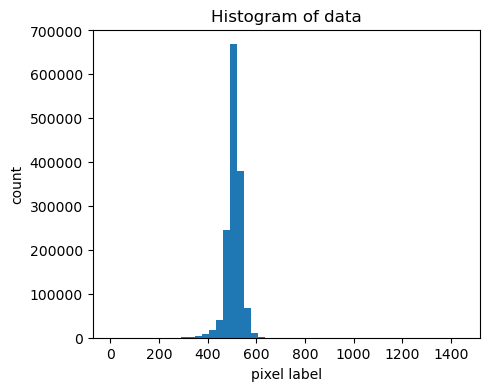

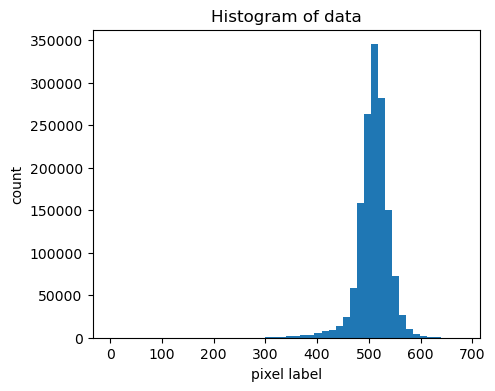

In [6]:
for i in range(5):
    pixel_values = data_files[i]["data"].ravel()
    plt.figure(figsize = (5,4))
    plt.hist(pixel_values, bins = 50)
    plt.title("Histogram of data")
    plt.xlabel("pixel label")
    plt.ylabel("count")

In [7]:
#x axis is the pixel value, probably related to color and intensity
#y xis is the frequency of that pixel in the image 
#bins is the range of values that organize the histogram into rectangles. This histogram has a new segmment every 50 units, therefore bins = 50
#depends on the fits file, but most of the data is between 400-600, with peaks at 500
#the data is pretty concentrated, and not spread out 
#the mean/median is around 500 units

In [8]:
images = np.array([img["data"] for img in data_files])
median = np.median(images, axis=0)
print(np.median(median))

510.0


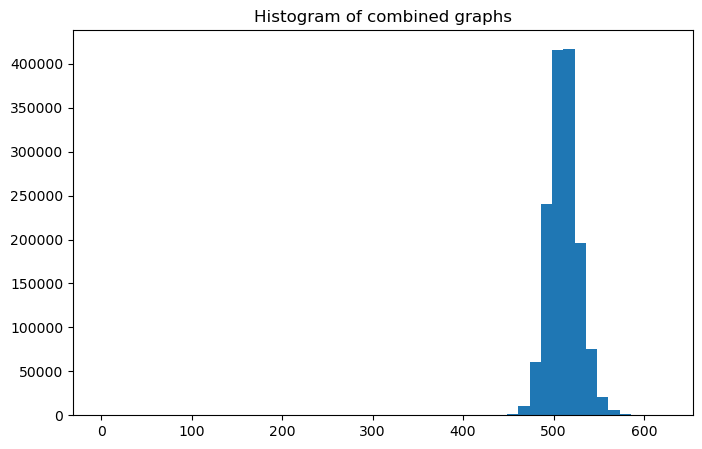

In [9]:
#the median is 510 pixel value
plt.figure(figsize = (8,5))
plt.hist(median.ravel(), bins = 50)
plt.title("Histogram of combined graphs")
plt.show()

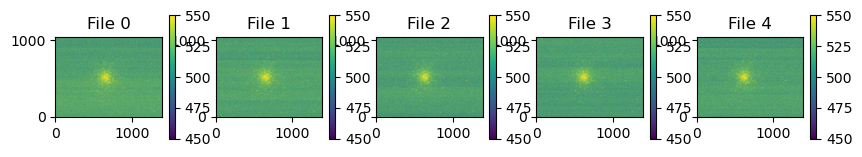

In [22]:
fig, axes = plt.subplots(1, 5, figsize = (10, 2))
for i in range(5):
    image = axes[i].imshow(data_files[i]["data"], origin = "lower", vmin = 450 , vmax = 550)
    axes[i].set_title(f"File {i}")
    fig.colorbar(image, ax=axes[i], shrink=0.8)
plt.show()


In [14]:
#this image is clearer, and sharply reveals the spot with the peak pixel value

In [23]:
fits.writeto("combined.fits", median, overwrite=True)